In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import neattext.functions as nfx

In [2]:
df = pd.read_csv("emotion.csv")

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.head())

Shape: (416809, 2)
Columns: Index(['text', 'emotion'], dtype='object')
                                                text  emotion
0  i feel awful about it too because it s my job ...        0
1                              im alone i feel awful        0
2  ive probably mentioned this before but i reall...        1
3           i was feeling a little low few days back        0
4  i beleive that i am much more sensitive to oth...        2


In [4]:
print("Nulls:", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Nulls: text       0
emotion    0
dtype: int64
Duplicates: 686


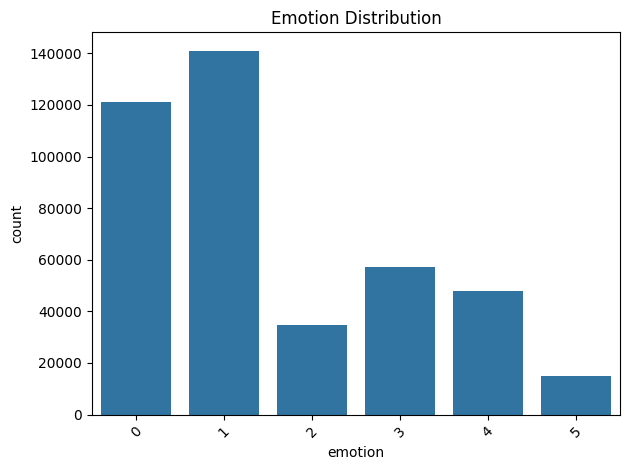

In [6]:
# Distribution of emotions
sns.countplot(x='emotion', data=df)
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import joblib

In [8]:
label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}
df["emotion"] = df["emotion"].map(label_map)

In [9]:
df["Clean_Text"] = df["text"].apply(nfx.remove_stopwords)
df["Clean_Text"] = df["Clean_Text"].apply(nfx.remove_special_characters)

In [10]:
X = df["Clean_Text"]
y = df["emotion"]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
vec = CountVectorizer()
X_train_vec = vec.fit_transform(X_train)
X_test_vec = vec.transform(X_test)

In [13]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

In [14]:
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.91      0.85      0.88     11339
        fear       0.84      0.82      0.83      9376
         joy       0.86      0.94      0.90     28247
        love       0.83      0.64      0.72      6853
     sadness       0.88      0.94      0.91     24504
    surprise       0.89      0.40      0.56      3043

    accuracy                           0.87     83362
   macro avg       0.87      0.77      0.80     83362
weighted avg       0.87      0.87      0.86     83362



In [15]:
# Save model and vectorizer
joblib.dump(model, "emotion_model.pkl")
joblib.dump(vec, "vectorizer.pkl")

['vectorizer.pkl']